### Imports

In [1]:
import json
import os
from typing import List

from IPython.display import Image, display
from json_repair import repair_json
from langchain.prompts import PromptTemplate
from langchain_community.chat_models import ChatOllama
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.output_parsers import JsonOutputParser
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

### LLM Definitions

In [2]:
relations_extractor_llm = "llama3.1"
relations_json_formatter_llm = "llama3.1"
summary_llm = "llama3.1"
summary_json_formatter_llm = "llama3.1"
name_date_llm = "llama3.1"
name_date_json_formatter_llm = "llama3.1"

### Relationship Extractor

In [3]:
llm = ChatOllama(
    model=relations_extractor_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
     You are an expert in analyzing financial circulars and extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. Start extracting relationships after the Title of the document.

    Relationships in the context is defined as mention of a particular document, circular, notification, laws, acts. in the current document. Extract the most meaniful single word relationship mentioned in the document. While mentioning the document, please only include the title of the document, date and other identifiers are not required. 
    
    Example of relationships include: superseded, amended, overturned, replaced, etc.

    <JSON Output Structure>
    "relations": {{
      "Document 1": "Relationship with current document",
      "Document 2": "Relationship with current document"
    }}
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

page_relations_extractor_chain = prompt | llm | JsonOutputParser()

/tmp/ipykernel_90113/4213896244.py:1: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(


In [4]:
llm = ChatOllama(
    model=relations_json_formatter_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    Given the Required Output JSON schema, you are required to format by combining individual string output into a single structured JSON format. Remove or Merge any duplicate or redundant information.

    <Unformatted Input>
    {unformatted_input}
    </Unformatted Input>

    <Formatted JSON Output Schema>
    "relations": {{
      "Document 1": "Relationship with current document",
      "Document 2": "Relationship with current document"
    }}
    </Formatted JSON Output Schema>

    """,
    input_variables=["pdf_content"],
)

relations_json_formatter_chain = prompt | llm | JsonOutputParser()

In [5]:
# pdf = PyPDFLoader('/workspace/fmc/agenticKG/langraphApproach/Existing Circular.pdf').load()
# output = ""

# for i in range(len(pdf)):
#     page_output = page_relations_extractor_chain.invoke({'pdf_content': pdf[i].page_content})
#     page_output = str(page_output)
#     output += page_output + "\n"

# output = relations_json_formatter_chain.invoke({'unformatted_input': output})
# output = repair_json(str(output))
# print(output)

### Summary Generator

In [6]:
llm = ChatOllama(
    model=summary_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are an expert in analyzing financial circulars and extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. 

    Summarize the content of the document. The summary should be concise and capture the essence of the document.
    

    <JSON Output Structure>
    "summary": "summary of the document"
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

summary_chain = prompt | llm | JsonOutputParser()

In [7]:
llm = ChatOllama(
    model=summary_json_formatter_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    Given the Required Output JSON schema, you are required to format by using the page wise summary to generate a single complete summary for the document and format it in JSON format. Remove or Merge any duplicate or redundant information.

    <Unformatted Input>
    {unformatted_input}
    </Unformatted Input>

    <Formatted JSON Output Schema>
    "summary": "summary of the document"
    </Formatted JSON Output Schema>
    """,
    input_variables=["pdf_content"],
)

summary_json_formatter_chain = prompt | llm | JsonOutputParser()

In [8]:
# pdf = PyPDFLoader('/workspace/fmc/agenticKG/langraphApproach/Existing Circular.pdf').load()
# output = ""

# for i in range(len(pdf)):
#     page_output = summary_chain.invoke({'pdf_content': pdf[i].page_content})
#     page_output = str(page_output)
#     output += page_output + "\n"

# output = summary_json_formatter_chain.invoke({'unformatted_input': output})
# output = repair_json(str(output))
# print(output)

### Name and Date Extractor

In [9]:
llm = ChatOllama(
    model=name_date_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are an expert in analyzing financial circulars and extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. 

    1. Name: Provide the name of the document mentioned at the very start not including RBI/Year/No
    2. Date of Issue: Find and extract the date when the circular was issued.
    
    <JSON Output Structure>
    "name": "The full name of the document",
    "date_of_issue": "The date when the circular was issued",
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

name_date_chain = prompt | llm | JsonOutputParser()

In [10]:
# pdf = PyPDFLoader('/workspace/fmc/agenticKG/langraphApproach/Existing Circular.pdf').load()
# output = name_date_chain.invoke({'pdf_content': pdf[0].page_content})
# print(output)

### State Definition

In [11]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        path: The document path.
        name: The name of the document.
        date_of_issue: The date when the circular was issued.
        summary: The summary of the document.
        relations: The relationships between the current document and other documents.
    """

    path: str
    name: str
    date_of_issue: str
    summary: str
    relations: List[str]

### Node Definitions

In [12]:
def extract_name_date(state):
    """
    Extract name and date of issue

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New keys added to state, name and date_of_issue, that contain the name and date of issue
    """
    print("---EXTRACTING NAME AND DATE---")
    pdf = PyPDFLoader(state["path"]).load()
    output = name_date_chain.invoke({"pdf_content": pdf[0].page_content})
    state["name"] = output["name"]
    state["date_of_issue"] = output["date_of_issue"]
    return state


def extract_relationships(state):
    """
    Extract relationships

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, relations, that contains the relationships between the current document and other documents
    """
    print("---EXTRACTING RELATIONSHIPS---")
    pdf = PyPDFLoader(state["path"]).load()
    output = ""
    for i in range(len(pdf)):
        page_output = page_relations_extractor_chain.invoke(
            {"pdf_content": pdf[i].page_content}
        )
        page_output = str(page_output)
        output += page_output + "\n"
    output = relations_json_formatter_chain.invoke({"unformatted_input": output})
    output = repair_json(str(output))
    output = json.loads(output)
    state["relations"] = output["relations"]
    return state


def summarize_document(state):
    """
    Summarize the document

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, summary, that contains the summary of the document
    """
    print("---SUMMARIZING DOCUMENT---")
    pdf = PyPDFLoader(state["path"]).load()
    output = ""
    for i in range(len(pdf)):
        page_output = summary_chain.invoke({"pdf_content": pdf[i].page_content})
        page_output = str(page_output)
        output += page_output + "\n"
    output = summary_json_formatter_chain.invoke({"unformatted_input": output})
    output = repair_json(str(output))
    output = json.loads(output)
    state["summary"] = output["summary"]
    return state


def format_output(state):
    """
    Format the output

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): The formatted output
    """
    print("---FORMATTING OUTPUT---")
    output = {
        "name": state["name"],
        "date_of_issue": state["date_of_issue"],
        "summary": state["summary"],
        "relations": state["relations"],
    }
    output = repair_json(str(output))
    output = json.loads(output)

    output_path = "./output/"
    os.makedirs(output_path, exist_ok=True)
    with open(f"{output_path}{state['name']}.json", "w") as f:
        json.dump(output, f)

    return state

### Graph Building

In [13]:
workflow = StateGraph(GraphState)

workflow.add_node("name_date", extract_name_date)
workflow.add_node("relationships", extract_relationships)
workflow.add_node("doc_summary", summarize_document)
workflow.add_node("output_formatting", format_output)

workflow.add_edge(START, "name_date")
workflow.add_edge("name_date", "relationships")
workflow.add_edge("relationships", "doc_summary")
workflow.add_edge("doc_summary", "output_formatting")
workflow.add_edge("output_formatting", END)

app = workflow.compile()

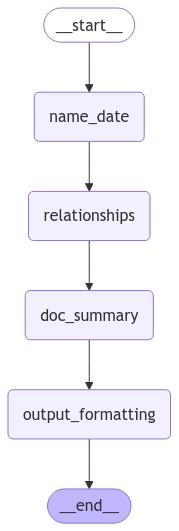

In [14]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Executing Graph

In [15]:
directory_path = "circulars/"
for filename in os.listdir(directory_path):
    print(f"Processing {filename}...")
    inputs = {
        "path": f"{directory_path}{filename}",
        "name": "",
        "date_of_issue": "",
        "summary": "",
        "relations": [],
    }
    for output in app.stream(inputs):
        for key, value in output.items():
            print("---" * 5)
            print(f"{key}: {value}")
            print("---" * 5)

Processing Withdrawn Circular 2.pdf...
---EXTRACTING NAME AND DATE---
---------------
name_date: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': 'May 1, 2018', 'summary': '', 'relations': []}
---------------
---EXTRACTING RELATIONSHIPS---
---------------
relationships: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': 'May 1, 2018', 'summary': '', 'relations': {'FEMA.20/2000-RB': 'amended', 'AP (DIR Series) Circular No. 24 dated April 27, 2018': 'amended', 'Companies Act, 2013': 'referenced', 'Foreign Exchange Management Act, 1999 (42 of 1999)': 'issued under'}}
---------------
---SUMMARIZING DOCUMENT---
---------------
doc_summary: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': 'May 1, 2018', 'summary': 'The Reserve Bank of India (RBI) has issued a circular to all authorized persons regarding the review of